# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [ ]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "../../"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
# import pandas as pd
# from pathlib import Path

# data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
# df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
# df.rename(columns={"year_month_day": "date"}, inplace=True)



repo_path = "../.." # for local development

import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'


## Below works for pandas 2.2.2, but not for the 3.0.1 that I have
# df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
# df.rename(columns={"year_month_day": "date"}, inplace=True)

## Works for pandas 3.0.1
# Read CSV and manually combine date columns
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Drop the individual date columns to clean up
df = df.drop(['year', 'month', 'day'], axis=1)



# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

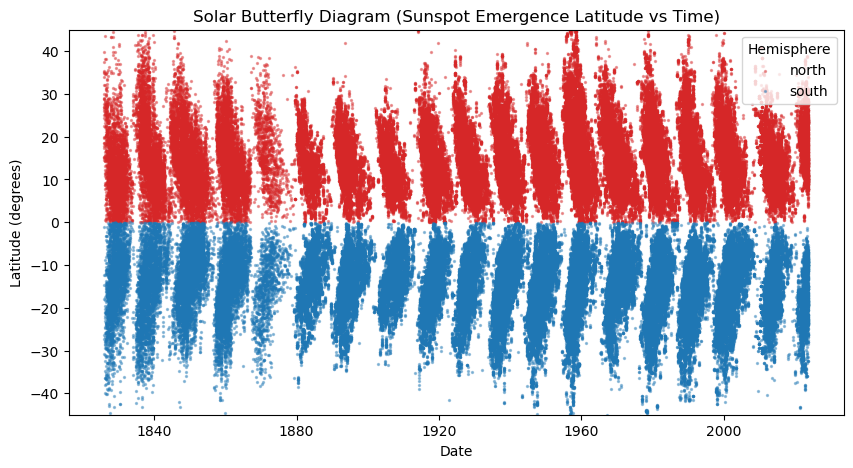

In [4]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


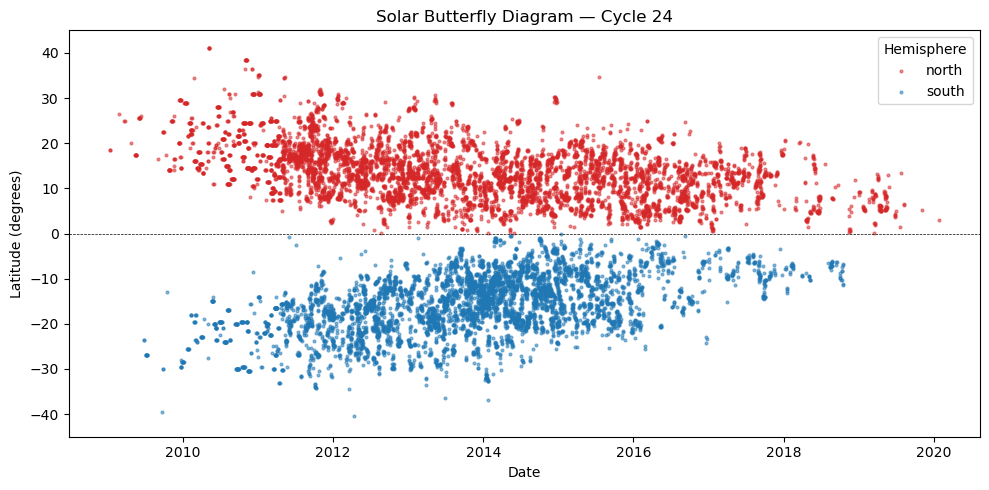

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [3]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_445319/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


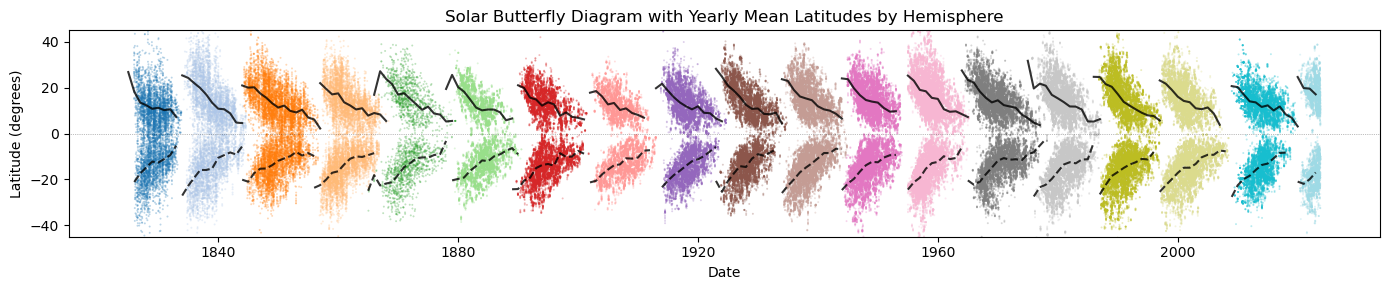

In [4]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]
    
    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
                linewidth=1.5, linestyle="-", alpha=0.8)
    
    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

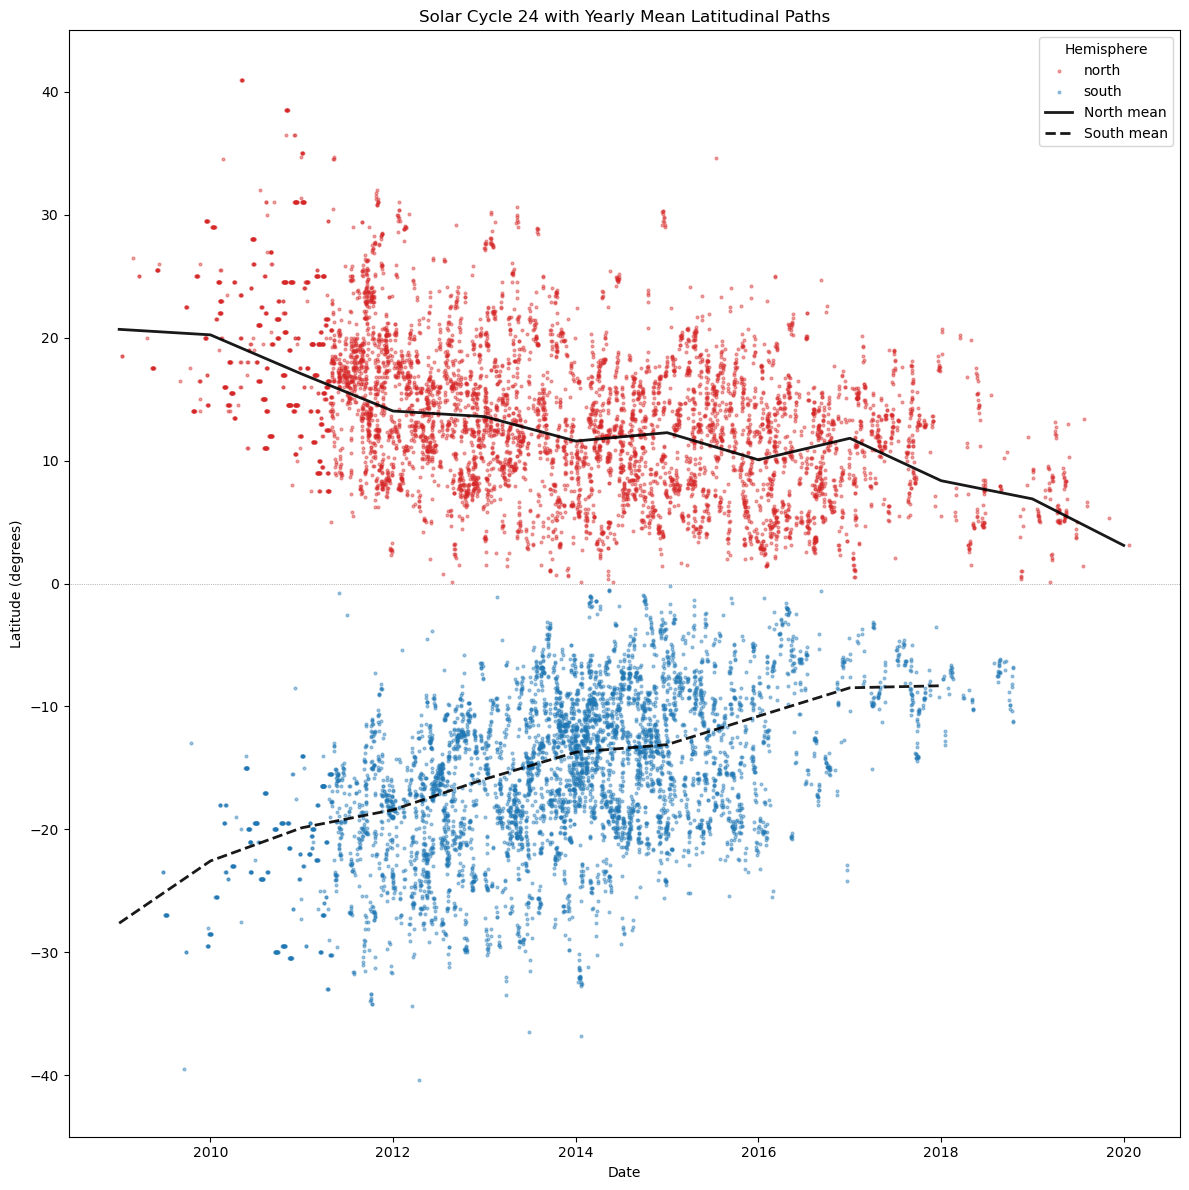

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [5]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


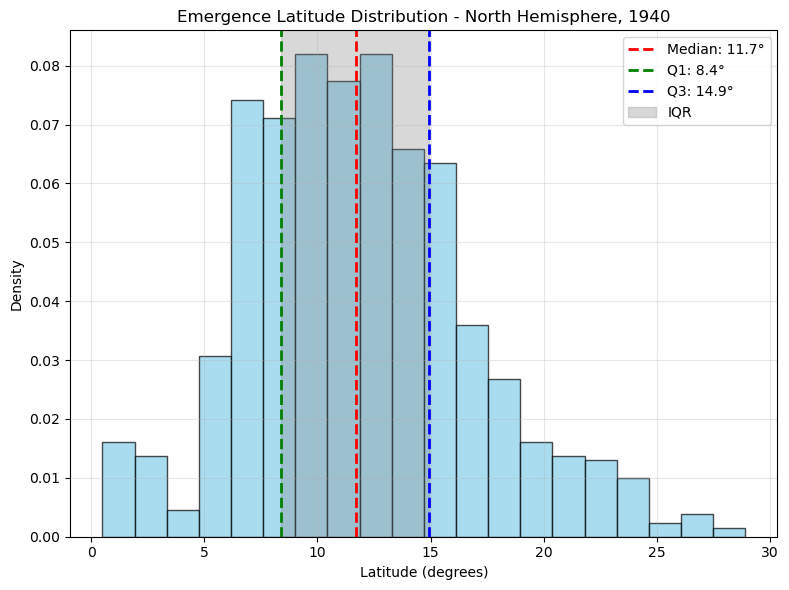

Year: 1940, Hemisphere: north
Number of sunspot groups: 920
Latitude range: [0.5°, 28.9°]


In [ ]:
# Cell completely generated by Claude Haiku 4.5 (probably)
# Some comments added afterhand to help decipher the AI code

# Task 6: Empirical Distribution for a Single Year

import numpy as np
# matplotlib is not imported because it should be done in a previous cell

# Variables to change for different graphs
year = 1940
hemisphere = 'north'  # 'north' or 'south'

# Filter data to the specified year and hemisphere
df_year_hemi = df[(df['date'].dt.year == year) & (df['hemisphere'] == hemisphere)].copy()   # a new copy of df is made, filtered to the year and hemisphere specified
latitudes = df_year_hemi['latitude']    # the latitudes of the new copy are saved in their own list

# Plot histogram (density-normalized)
fig, ax = plt.subplots(figsize=(8, 6))  # initialize the figure
ax.hist(latitudes, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')    # plot the latitudes on a histogram with 20 bins, density normalized, with a transparency of 0.7

# Compute median, Q1, Q3
median = np.median(latitudes)       # compute the median (q2, middle of the data) using numpy
q1 = np.percentile(latitudes, 25)   # compute q1 (25% of the data) using numpy
q3 = np.percentile(latitudes, 75)   # compute q3 (75% of the data) using numpy

# Add vertical lines for median, Q1, Q3
ax.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median: {median:.1f}°')
ax.axvline(q1, color='green', linestyle='--', linewidth=2, label=f'Q1: {q1:.1f}°')
ax.axvline(q3, color='blue', linestyle='--', linewidth=2, label=f'Q3: {q3:.1f}°')

# Shade the IQR
ax.axvspan(q1, q3, alpha=0.3, color='gray', label='IQR')

# Labels and title
ax.set_title(f'Emergence Latitude Distribution - {hemisphere.capitalize()} Hemisphere, {year}')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()  # I like this, gotta remember this one, minimizes whitespace around the figure
plt.show()

# print auxiliary data
print(f'Year: {year}, Hemisphere: {hemisphere}')
print(f'Number of sunspot groups: {len(df_year_hemi)}')
print(f'Latitude range: [{latitudes.min():.1f}°, {latitudes.max():.1f}°]')

Definitions:
- Q1: The first quartile. 25% of the data lies below this point. The median is the second quartile.
- Q3: The third quartile. 75% of the data lies below this point.
- IQR: Stands for "InterQuartile Range." It is the difference between Q3 and Q1; it contains the middle 50% of the data.

What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?

- The distribution is not symmetric; generally there seems to be many sunspots around the median, but the median is closer to the equator. As latitude increases beyond the median, it seems like the number of sunspots tapers of until about 30 degrees latitude.
- The shape definitely changes between years. This is expected, because each solar cycle is about 11 years long and sunspots generally appear at higher latitudes near the beginning of a cycle and closer to the equator as the cycle ends.

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


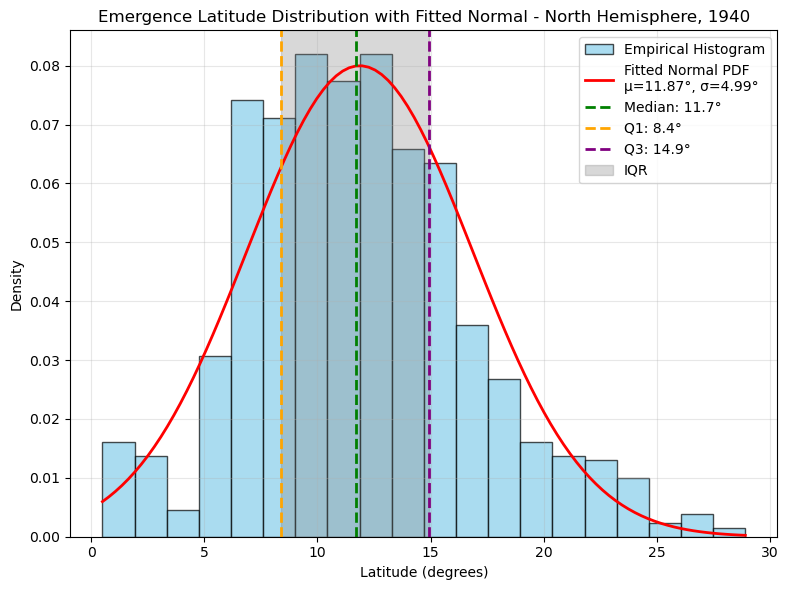

Year: 1940, Hemisphere: north
Fitted Normal parameters: μ = 11.87°, σ = 4.99°
Empirical median: 11.70°
Number of sunspot groups: 920


In [6]:
# Cell completely generated by Claude Haiku 4.5 (probably, might be grok)

# Task 7: Fitting an Analytical Distribution

import numpy as np
import scipy.stats as stats

# Use the same year and hemisphere as Task 6
# if task 6 is always run first, we could leave some of this setup out. for now we'll keep it in
year = 1940
hemisphere = 'north'

# Filter data to the specified year and hemisphere
df_year_hemi = df[(df['date'].dt.year == year) & (df['hemisphere'] == hemisphere)].copy()
latitudes = df_year_hemi['latitude']

# Fit a Normal (Gaussian) distribution
mu, sigma = stats.norm.fit(latitudes)   # use the statistics from scipy to find the normal distribution

# Create a grid of x values for the PDF
x_grid = np.linspace(latitudes.min(), latitudes.max(), 100) # just a grid from the minimum to the maximum latitude
pdf_fitted = stats.norm.pdf(x_grid, mu, sigma)  # the normal distribution from above is plotted on the grid

# Plot histogram (density-normalized)
fig, ax = plt.subplots(figsize=(8, 6))  # initialize the figure
ax.hist(latitudes, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Empirical Histogram')   # plot the histogram for comparison

# Overlay the fitted PDF
ax.plot(x_grid, pdf_fitted, 'r-', linewidth=2, label=f'Fitted Normal PDF\nμ={mu:.2f}°, σ={sigma:.2f}°') # add the normal distribution to the figure

# do everything else like the previous section

# Compute median, Q1, Q3 for reference
median = np.median(latitudes)
q1 = np.percentile(latitudes, 25)
q3 = np.percentile(latitudes, 75)

# Add vertical lines for median, Q1, Q3
ax.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.1f}°')
ax.axvline(q1, color='orange', linestyle='--', linewidth=2, label=f'Q1: {q1:.1f}°')
ax.axvline(q3, color='purple', linestyle='--', linewidth=2, label=f'Q3: {q3:.1f}°')

# Shade the IQR
ax.axvspan(q1, q3, alpha=0.3, color='gray', label='IQR')

# Labels and title
ax.set_title(f'Emergence Latitude Distribution with Fitted Normal - {hemisphere.capitalize()} Hemisphere, {year}')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Year: {year}, Hemisphere: {hemisphere}')
print(f'Fitted Normal parameters: μ = {mu:.2f}°, σ = {sigma:.2f}°')
print(f'Empirical median: {median:.2f}°')
print(f'Number of sunspot groups: {len(df_year_hemi)}')

Does it fit well? Where does it agree with the data and where does it fail?
- It looks like it fits very well.
- It does seem to fail near the IQR, at least for 1940 in the north hemisphere. However, I think the fit is very good for an analytical approximation of the distribution of sunspots.
The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?
- mu is the mean, which physically represents the center of where sunspots prefer to emerge.
- sigma is the standard deviation, which physically represents how many sunspots appear near the mean. If sigma is large, then not many of the sunspots are near the mean. If sigma is small, more of the sunspots are appearing near the mean.

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


/tmp/ipykernel_1954938/3543486866.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_years)


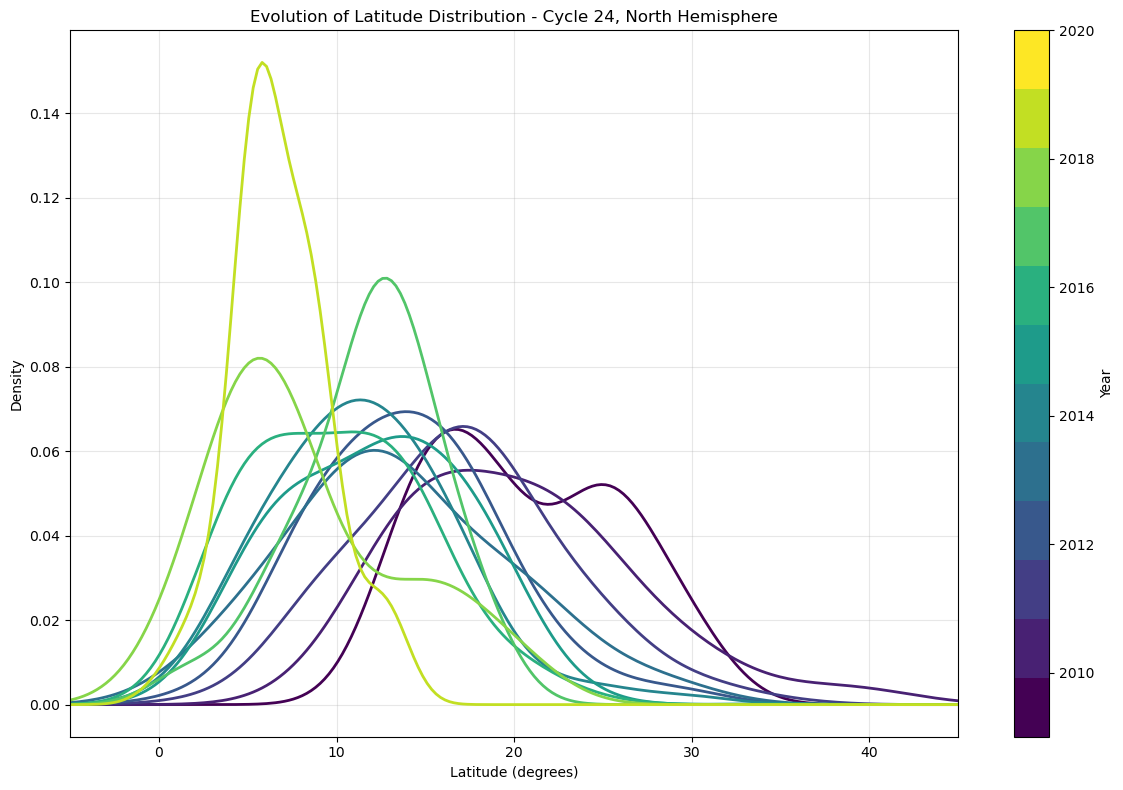

Cycle 24, north hemisphere
Years with data: [np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Total sunspot groups: 6473

Summary by year:
2009: n=65, mean=20.7°, median=20.0°
2010: n=398, mean=20.2°, median=20.0°
2011: n=1153, mean=17.0°, median=17.0°
2012: n=1009, mean=14.0°, median=13.7°
2013: n=891, mean=13.6°, median=12.8°
2014: n=898, mean=11.6°, median=11.3°
2015: n=800, mean=12.3°, median=12.5°
2016: n=712, mean=10.1°, median=10.0°
2017: n=356, mean=11.8°, median=12.4°
2018: n=96, mean=8.4°, median=7.3°
2019: n=94, mean=6.9°, median=6.1°
2020: n=1, mean=3.1°, median=3.1°


In [15]:
# Cell almost completely generated by Claude Haiku 4.5 (probably, might be grok)

# Task 8: Distribution Evolution Through a Solar Cycle

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Variables to change for different analyses
cycle_number = 24
hemisphere = 'north'  # 'north' or 'south'
smoothing_parameter = 0.5

# Filter data to the specified cycle and hemisphere
df_cycle_hemi = df[(df['CYCLE'] == cycle_number) & (df['hemisphere'] == hemisphere)].copy()

# Get unique years in this cycle
years = sorted(df_cycle_hemi['date'].dt.year.unique())

# Create a colormap for years
n_years = len(years)
cmap = cm.get_cmap('viridis', n_years)
year_colors = {year: cmap(i) for i, year in enumerate(years)}

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create a grid for KDE evaluation
x_grid = np.linspace(-5, 45, 200)  # Latitude range from -5° to 45°

# For each year, compute and plot KDE
for year in years:
    df_year = df_cycle_hemi[df_cycle_hemi['date'].dt.year == year]
    latitudes = df_year['latitude'].values

    if len(latitudes) > 5:  # Only compute KDE if we have enough data points
        # Fit KDE
        kde = stats.gaussian_kde(latitudes, bw_method=smoothing_parameter)

        # Evaluate KDE on the grid
        kde_values = kde(x_grid)

        # Plot the KDE
        ax.plot(x_grid, kde_values, color=year_colors[year], linewidth=2,
                label=f'{year} (n={len(latitudes)})')

# Add labels and formatting
ax.set_title(f'Evolution of Latitude Distribution - Cycle {cycle_number}, {hemisphere.capitalize()} Hemisphere')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.set_xlim(-5, 45)
ax.grid(True, alpha=0.3)

# Create a colorbar to show year progression
sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(years), vmax=max(years)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Year')

# Alternative: legend (uncomment if preferred over colorbar)
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f'Cycle {cycle_number}, {hemisphere} hemisphere')
print(f'Years with data: {years}')
print(f'Total sunspot groups: {len(df_cycle_hemi)}')

# Summary statistics by year
print('\nSummary by year:')
for year in years:
    df_year = df_cycle_hemi[df_cycle_hemi['date'].dt.year == year]
    if len(df_year) > 0:
        mean_lat = df_year['latitude'].mean()
        median_lat = df_year['latitude'].median()
        print(f'{year}: n={len(df_year)}, mean={mean_lat:.1f}°, median={median_lat:.1f}°')

Definitions:
- KDE: Kernel Density Estimate. A method to turn a dataset with a finite number of samples into a continuous function. The smoothing parameter specifies how far the kernel should reach from the current position to estimate the function. If it's 0, then there is no smoothing and the result is a sum of delta functions centered at the coordinates of the analyzed samples. If it's infinity, then the estimate is the shape of the used kernel centered at the mean (the data is completely smoothed).

Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?
- Yes, the distributions are shifting toward the equator as the cycle progresses.
- It's a little hard to see if the width changes, but it looks like the distribution in earlier years of the cycle have a wider distribution than years near the end of the cycle.